**"Aprendiendo a Detectar Clientes en Riesgo: Estrategias Analíticas para el Churn Bancario"**

Práctico n°2
Exploración y Curación

Objetivos:
Curar el set de datos inicial y prepararlo para un modelo de clasificación.

Consigna n°1: limpieza de datos

Analizar si existen valores faltantes y optar por el tratamiento adecuado (eliminarlos, considerarlos, normalizarlos, etc ) investigando todos los métodos disponibles para éste inconveniente.
Seleccionar las variables en las cuales ustedes observen Outliers. Discutir posibles motivos y optar por avanzar con una política.
Seleccionar alguna variable que presente alguna inconsistencia con el set de datos. Discutir posibles causales y optar por un tratamiento para ésta variable.
¿Existen ids duplicados? ¿Existen datos duplicados? En caso de haberlos, comentar recomendaciones a seguir. Incorporar algunos gráficos que permitan describir las situaciones

Consigna n°2: Feature engineering
Crear al menos 6 nuevas variables a partir de las variables existentes. Ej: Monto Promedio por Transacción: Total_Trans_Amt / Total_Trans_Ct, Porcentaje de inactividad anual:Months_Inactive_12_mon / 12 , Agrupar meses de antigüedad en segmentos (nuevo cliente, intermedio, maduro), etc.


Consigna n°3: preparación del dataset

Convertir a dummy las variables que utilizaran en el próximo práctico con el objetivo de construir un modelo de clasificación.
Dejar el nuevo dataset curado y listo para ser utilizado en un nuevo repositorio.


Los incisos anteriores están orientados a mejorar la consistencia y calidad del dataset, lo que permitirá obtener mejores resultados en próximos análisis. En ciencias de datos estos procesos son continuos en las distintas etapas de análisis. Es decir que si los datos requieren de mayor procesamiento , vamos a volver a ésta etapa inicial para sacar mayor provecho.

Entregas:

Breve informe (no más de 2 o 3 páginas) en el cual se explique qué detectaron en el set de datos, qué interpretación le dieron, alternativas de solución y propuesta.
El dataset con los cambios implementados en cuanto a curación y normalización.
Notebook que refleje el trabajo realizado.


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = 'https://raw.githubusercontent.com/chrismartinezML/DiplodatosFAMAF_2025/refs/heads/main/Churn_CreditCardPrediction.csv'
df = pd.read_csv(url)

### Analisis de valores faltantes

In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    if 'Unknown' in df[col].unique():
        count = df[col].value_counts()['Unknown']
        percentage = (count / len(df)) * 100
        print(f" - Columna '{col}': {count} valores 'Unknown' ({percentage:.2f}%).")

 - Columna 'Education_Level': 1519 valores 'Unknown' (15.00%).
 - Columna 'Marital_Status': 749 valores 'Unknown' (7.40%).
 - Columna 'Income_Category': 1112 valores 'Unknown' (10.98%).


A los valores Unknown los trataremos como null, y los imputaremos usando la tecnica de KNN y la media, analizaremos la distribucion antes y despues de la imputacion

Imputacion usando la media

In [ ]:
from sklearn.impute import SimpleImputer

UnknownColumns = ['Education_Level', 'Marital_Status', 'Income_Category']
df_cat_imputed = df.copy()
df_cat_imputed[UnknownColumns] = df_cat_imputed[UnknownColumns].replace("Unknown", np.nan)
imputer = SimpleImputer(strategy='most_frequent')
df_cat_imputed[UnknownColumns] = imputer.fit_transform(df_cat_imputed[UnknownColumns])

Imputacion usando KNN

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import OrdinalEncoder

df_knn = df.copy()
df_knn = df_knn.replace("Unknown", np.nan)

cat_cols = df_knn.select_dtypes(include='object').columns

encoder = OrdinalEncoder()
df_knn[cat_cols] = encoder.fit_transform(df_knn[cat_cols])

imputer = IterativeImputer(random_state=10, estimator=KNeighborsRegressor())
df_imputed = imputer.fit_transform(df_knn)

df_imputed = pd.DataFrame(df_imputed, columns=df_knn.columns)

df_imputed[cat_cols] = encoder.inverse_transform(df_imputed[cat_cols].round().astype(int))

/tmp/ipython-input-3560742067.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axs[i, 0], palette='Blues')
/tmp/ipython-input-3560742067.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_cat_imputed[col], ax=axs[i, 1], palette='Oranges')
/tmp/ipython-input-3560742067.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_imputed[col], ax=axs[i, 2], palette='Greens')
/tmp/ipython-input-3560742067.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. A

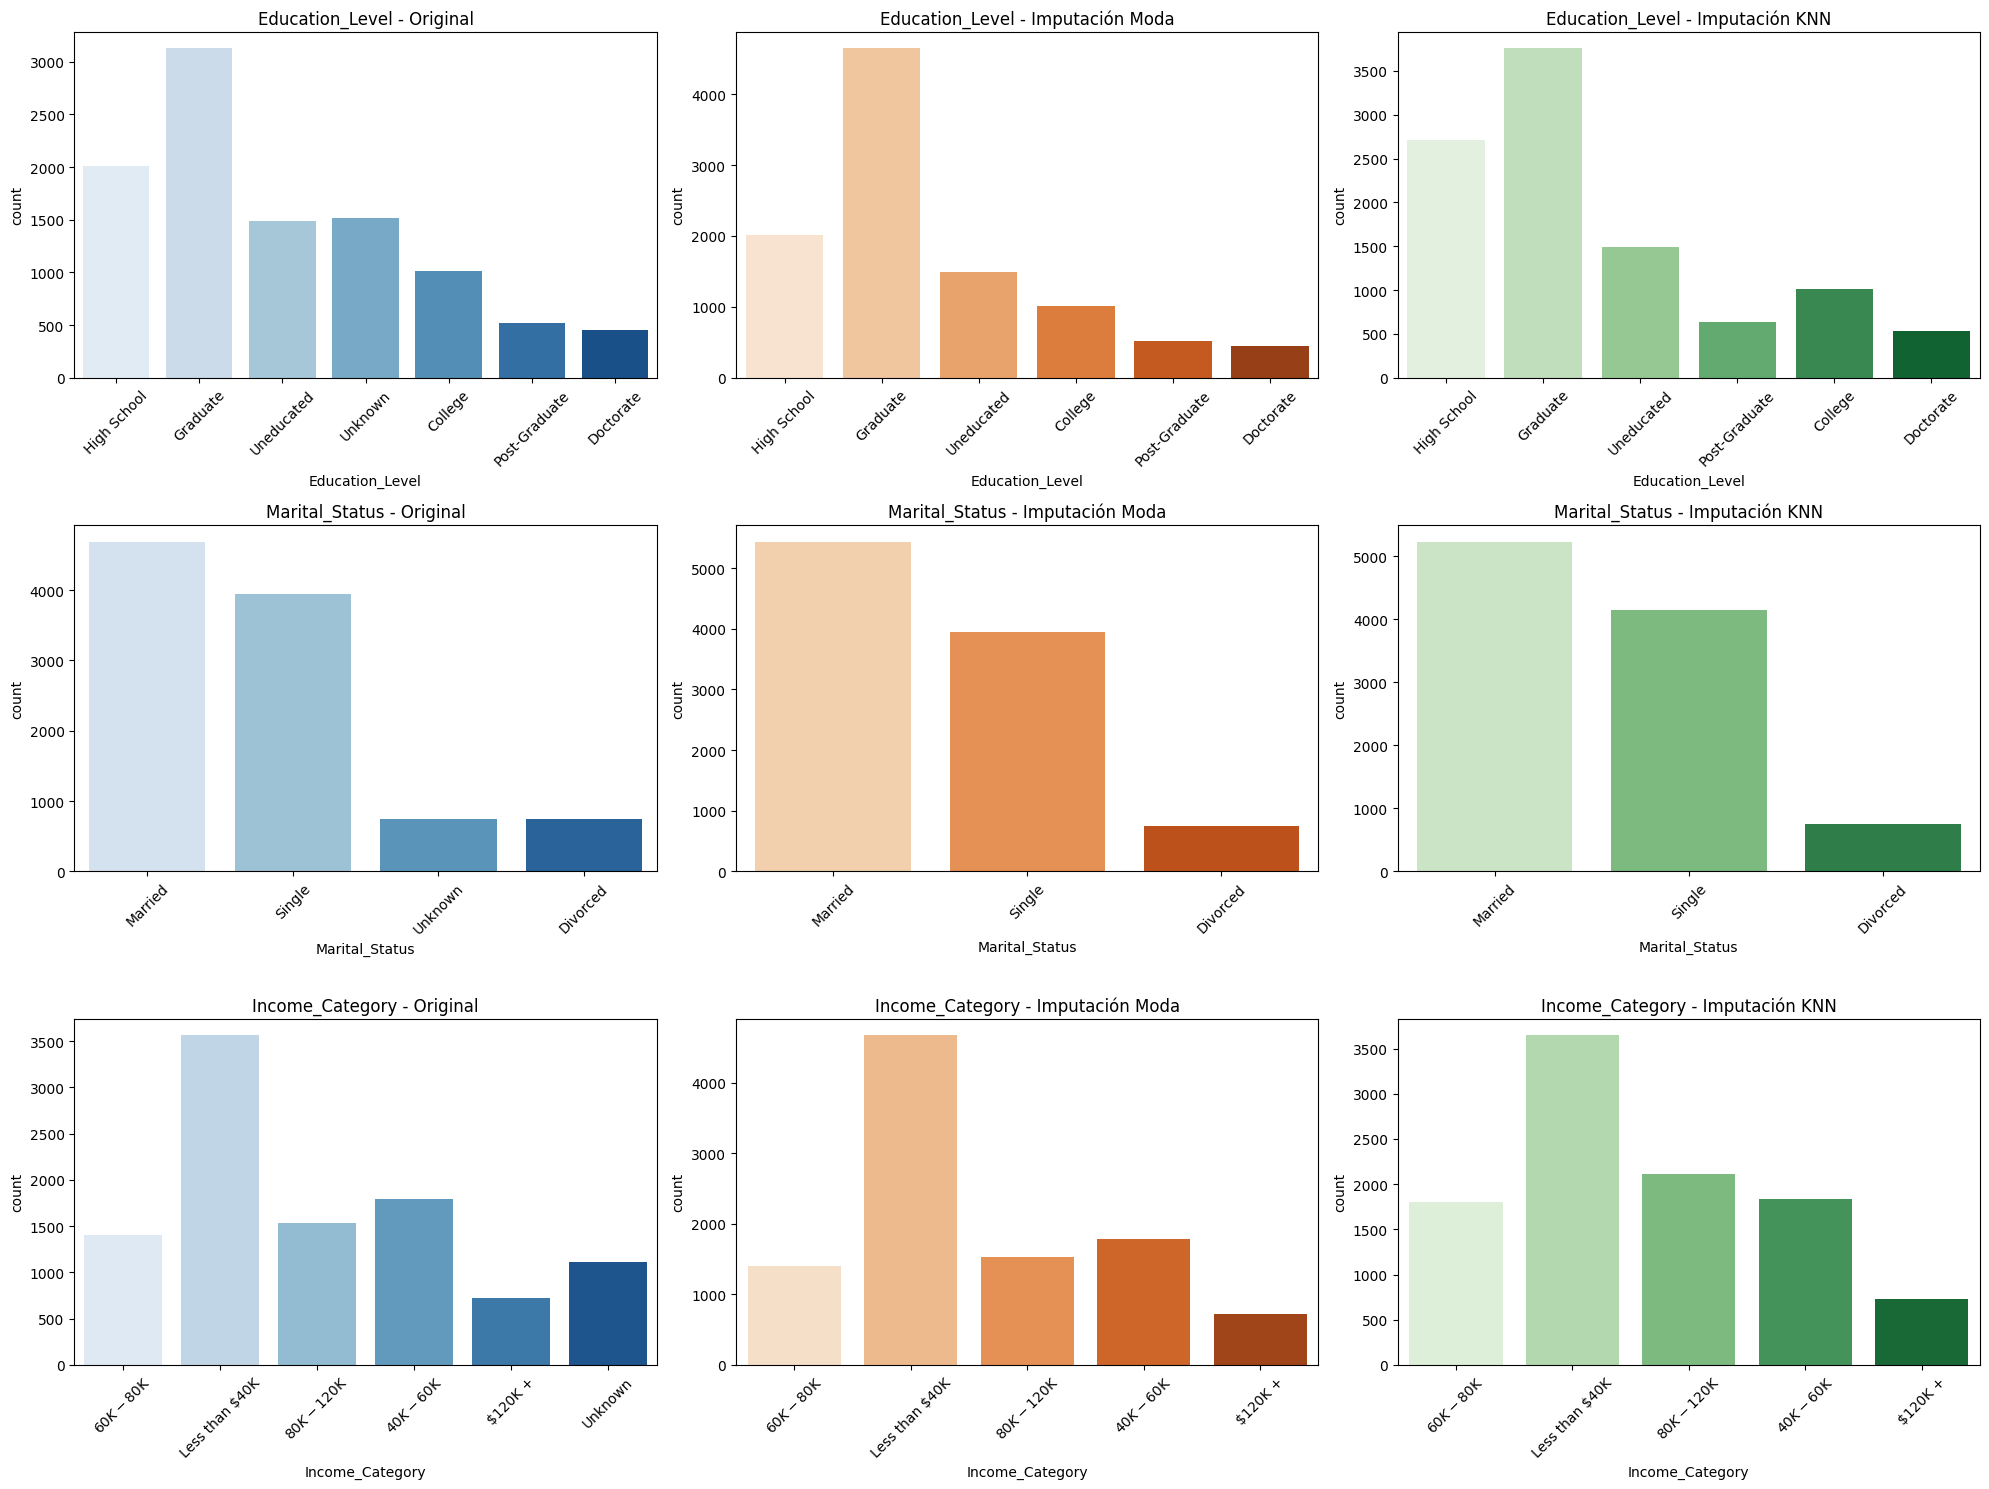

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols = UnknownColumns


fig, axs = plt.subplots(len(cols), 3, figsize=(20, 5 * len(cols)))

for i, col in enumerate(cols):
    # Original
    sns.countplot(x=df[col], ax=axs[i, 0], palette='Blues')
    axs[i, 0].set_title(f"{col} - Original")
    axs[i, 0].tick_params(axis='x', rotation=45)

    # Imputación por moda
    sns.countplot(x=df_cat_imputed[col], ax=axs[i, 1], palette='Oranges')
    axs[i, 1].set_title(f"{col} - Imputación Moda")
    axs[i, 1].tick_params(axis='x', rotation=45)

    # Imputación KNN (no escalado)
    sns.countplot(x=df_imputed[col], ax=axs[i, 2], palette='Greens')
    axs[i, 2].set_title(f"{col} - Imputación KNN")
    axs[i, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Podemos ver que al imputar usando KNN cambia un poco la distribucion de las variables asi que vamos quedarnos con la imputacion por valor mas frecuente


### 1.2: Análisis de Outliers ###


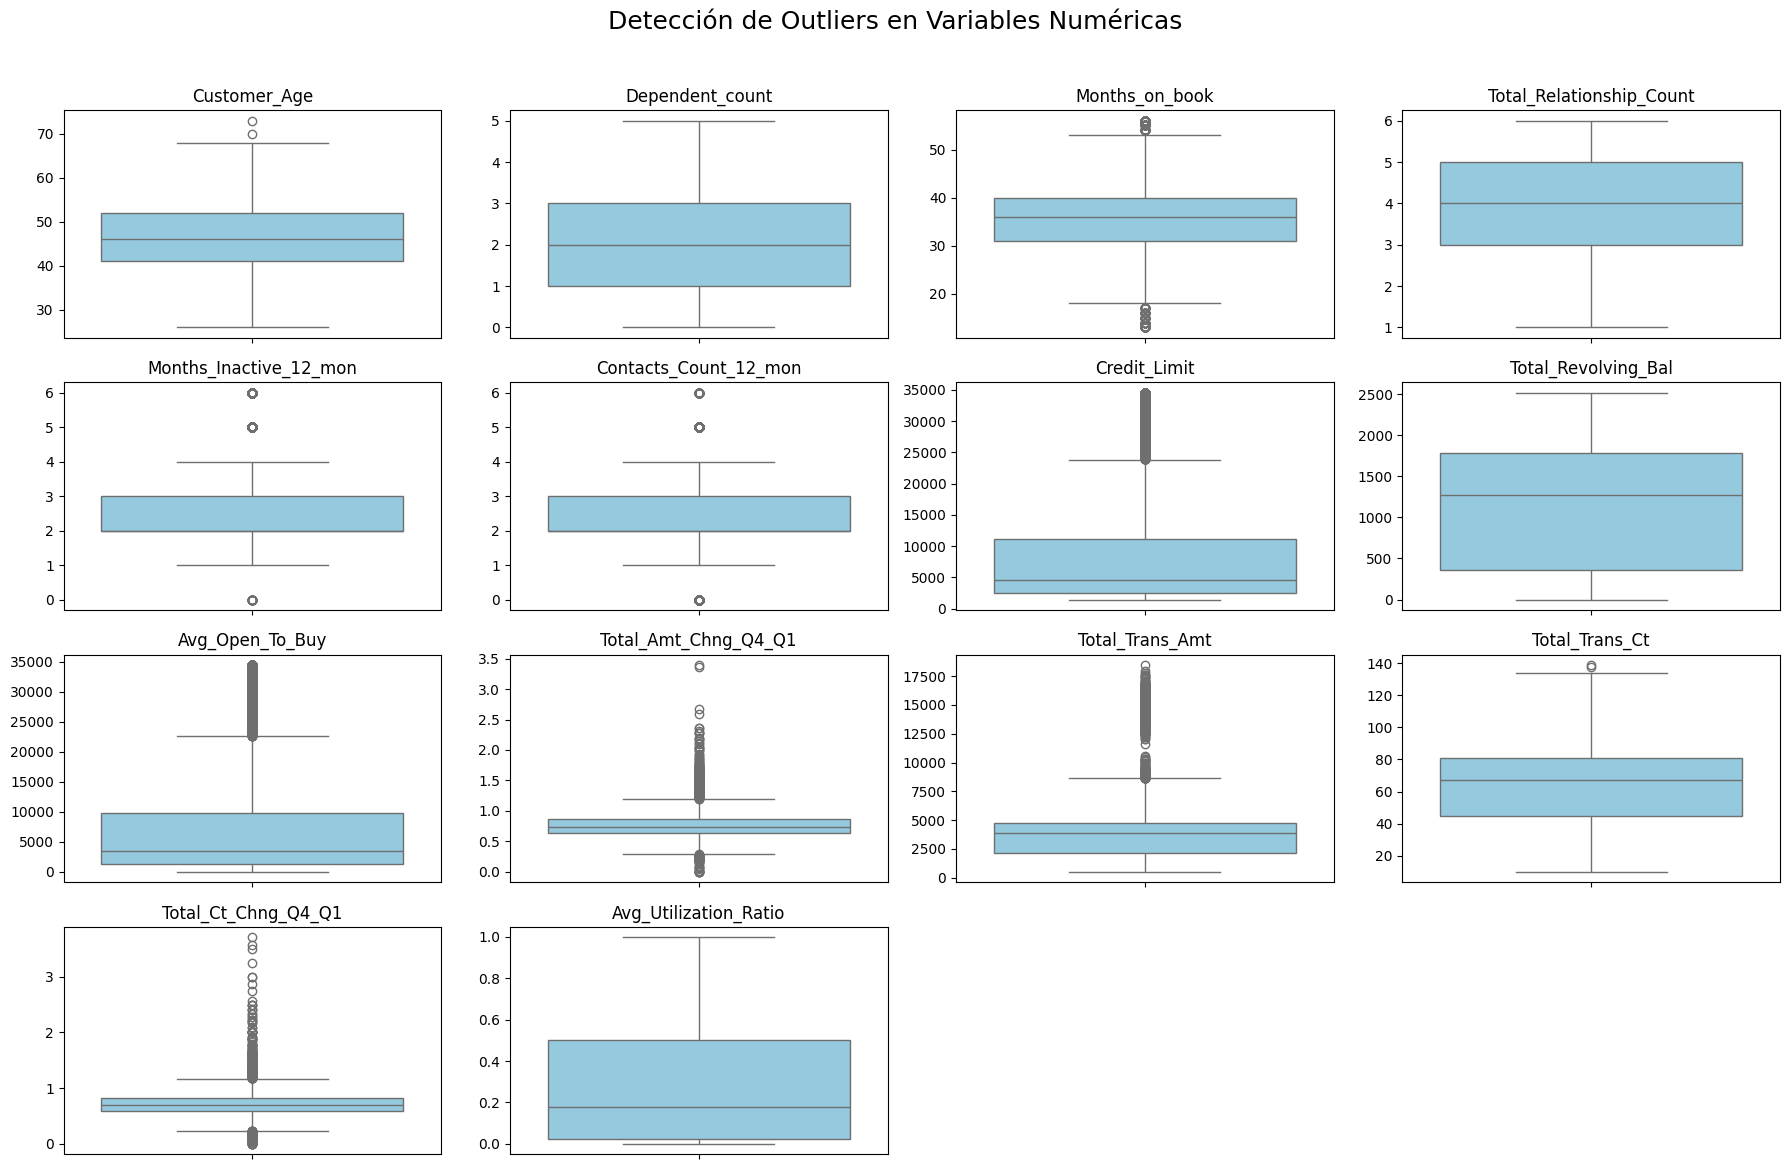


[Política de Tratamiento] Los outliers se consideran válidos y no serán eliminados.


In [ ]:
print("\n### 1.2: Análisis de Outliers ###")
numerical_cols = df_cat_imputed.select_dtypes(include=np.number).columns.drop('CLIENTNUM')
plt.figure(figsize=(18, 12))
plt.suptitle('Detección de Outliers en Variables Numéricas', fontsize=18, y=0.97)
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df_cat_imputed[col], color='skyblue')
    plt.title(col, fontsize=12); plt.ylabel('')
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
print("\n[Política de Tratamiento] Los outliers se consideran válidos y no serán eliminados.")



### 1.4: Análisis de Duplicados ###
IDs de cliente duplicados: 0
Filas duplicadas: 0
Conclusión: El dataset está libre de duplicados.


/tmp/ipython-input-1161539427.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition_Flag', data=df_cat_imputed, palette={'Existing Customer': '#2ecc71', 'Attrited Customer': '#e74c3c'})


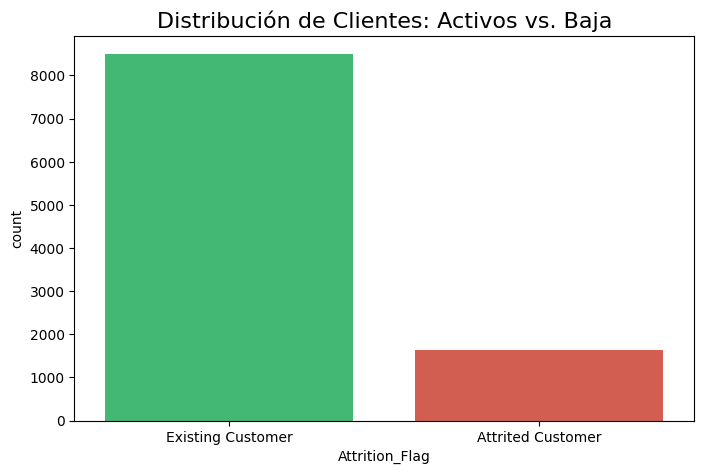

In [ ]:
print("\n### 1.4: Análisis de Duplicados ###")
print(f"IDs de cliente duplicados: {df_cat_imputed['CLIENTNUM'].duplicated().sum()}")
print(f"Filas duplicadas: {df_cat_imputed.duplicated().sum()}")
print("Conclusión: El dataset está libre de duplicados.")
plt.figure(figsize=(8, 5))
sns.countplot(x='Attrition_Flag', data=df_cat_imputed, palette={'Existing Customer': '#2ecc71', 'Attrited Customer': '#e74c3c'})
plt.title('Distribución de Clientes: Activos vs. Baja', fontsize=16)
plt.show()

### CONSIGNA N°2: FEATURE ENGINEERING

In [ ]:
df_final = df_cat_imputed.copy()
epsilon = 1e-6

print("Creando nuevas variables para mejorar la capacidad predictiva del modelo:\n")
# 1. Monto Promedio por Transacción
df_final['Avg_Transaction_Value'] = df_final['Total_Trans_Amt'] / (df_final['Total_Trans_Ct'] + epsilon)
# 2. Ratio de Inactividad vs Actividad
df_final['Inactive_vs_Active_Ratio'] = df_final['Months_Inactive_12_mon'] / (12 - df_final['Months_Inactive_12_mon'] + epsilon)
# 3. Ratio de Utilización del Crédito (Recalculado para asegurar consistencia)
df_final['Utilization_Ratio_Manual'] = df_final['Total_Revolving_Bal'] / (df_final['Credit_Limit'] + epsilon)
# 4. Tasa de Crecimiento de Transacciones
df_final['Transaction_Growth_Q4_Q1'] = df_final['Total_Ct_Chng_Q4_Q1'] - df_final['Total_Amt_Chng_Q4_Q1']
# 5. Segmentación por Antigüedad (Categórica)
df_final['Tenure_Segment'] = pd.qcut(df_final['Months_on_book'], q=4, labels=['Nuevo', 'Establecido', 'Leal', 'Veterano'])
# 6. Indicador de Cliente "Durmiente"
df_final['Is_Dormant'] = ((df_final['Months_Inactive_12_mon'] >= 4) & (df_final['Total_Trans_Amt'] < 3000)).astype(int)

print("Nuevas variables creadas:")
display(df_final[['Avg_Transaction_Value', 'Inactive_vs_Active_Ratio', 'Utilization_Ratio_Manual', 'Transaction_Growth_Q4_Q1', 'Tenure_Segment', 'Is_Dormant']].head())

Creando nuevas variables para mejorar la capacidad predictiva del modelo:

Nuevas variables creadas:


,Avg_Transaction_Value,Inactive_vs_Active_Ratio,Utilization_Ratio_Manual,Transaction_Growth_Q4_Q1,Tenure_Segment,Is_Dormant
0,27.238095,0.090909,0.061224,0.290,Leal,0
1,39.121211,0.090909,0.104651,2.173,Veterano,0
2,94.349995,0.090909,0.000000,-0.261,Establecido,0
3,58.549997,0.500000,0.759734,0.928,Establecido,1
4,29.142856,0.090909,0.000000,0.325,Nuevo,0


### CONSIGNA N°3: PREPARACIÓN FINAL Y GUARDADO DEL DATASET

In [14]:


# **CORRECCIÓN IMPORTANTE**: Se usa .apply() para una conversión más robusta de la variable objetivo.
df_final['Attrition_Flag'] = df_final['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)
print("Variable objetivo 'Attrition_Flag' convertida a 1 (Churn) y 0 (No Churn) de forma segura.")

# Identificar todas las columnas categóricas para convertirlas a variables dummy
categorical_cols_to_dummy = df_final.select_dtypes(include=['object', 'category']).columns

# Aplicar One-Hot Encoding
df_final = pd.get_dummies(df_final, columns=categorical_cols_to_dummy, drop_first=True)
print(f"Variables categóricas convertidas a dummies: {list(categorical_cols_to_dummy)}")

df_final.drop(columns='CLIENTNUM', inplace=True, errors='ignore')
print("Columna 'CLIENTNUM' eliminada.")

df_final.replace([np.inf, -np.inf], np.nan, inplace=True)
if df_final.isnull().sum().sum() > 0:
    df_final.fillna(df_final.median(), inplace=True)
    print("Valores nulos o infinitos restantes han sido imputados con la mediana.")
else:
    print("El dataset final está completo, sin valores nulos.")

# --- Entregable Final: Guardar el Dataset Curado ---
print("\n" + "-"*60)
print("El dataset curado está listo para ser guardado y utilizado en el próximo práctico.")
print(f"Dimensiones finales: {df_final.shape[0]} filas y {df_final.shape[1]} columnas.")

output_path = '/content/drive/MyDrive/Churn_CreditCard_Curated.csv'
try:
    df_final.to_csv(output_path, index=False)
    print(f"\n✅ ¡Éxito! El dataset final ha sido guardado en: '{output_path}'")
except Exception as e:
    print(f"\nERROR al guardar el archivo: {e}")

print("\nVisualización de las primeras 5 filas del dataset final:")
display(df_final.head())

Variable objetivo 'Attrition_Flag' convertida a 1 (Churn) y 0 (No Churn) de forma segura.
Variables categóricas convertidas a dummies: []
Columna 'CLIENTNUM' eliminada.
El dataset final está completo, sin valores nulos.

------------------------------------------------------------
El dataset curado está listo para ser guardado y utilizado en el próximo práctico.
Dimensiones finales: 10127 filas y 38 columnas.

✅ ¡Éxito! El dataset final ha sido guardado en: '/content/drive/MyDrive/Churn_CreditCard_Curated.csv'

Visualización de las primeras 5 filas del dataset final:


,Attrition_Flag,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,...,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Tenure_Segment_Establecido,Tenure_Segment_Leal,Tenure_Segment_Veterano
0,0,45,3,39,5,1,3,12691.0,777,11914.0,...,False,True,False,False,False,False,False,False,True,False
1,0,49,5,44,6,1,2,8256.0,864,7392.0,...,False,False,False,True,False,False,False,False,False,True
2,0,51,3,36,4,1,0,3418.0,0,3418.0,...,False,False,True,False,False,False,False,True,False,False
3,0,40,4,34,3,4,1,3313.0,2517,796.0,...,False,False,False,True,False,False,False,True,False,False
4,0,40,3,21,5,1,0,4716.0,0,4716.0,...,False,True,False,False,False,False,False,False,False,False


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
